In [14]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D

df = pl.read_parquet("out/*.parquet")

df

iterations,invalidation_method,page_number,compressed_size,uncompressed_size,compression_time,decompression_time,version,trace,alg,iter,inv
i64,i64,i64,i64,i64,i64,i64,i32,str,str,str,str
10,1,1,280,4096,9149,5902,1,"""ollama""","""WKdm""","""10""","""clflush"""
10,1,2,504,4096,6484,5024,1,"""ollama""","""WKdm""","""10""","""clflush"""
10,1,3,676,4096,7227,5895,1,"""ollama""","""WKdm""","""10""","""clflush"""
10,1,4,320,4096,6083,4793,1,"""ollama""","""WKdm""","""10""","""clflush"""
10,1,5,1284,4096,9288,6350,1,"""ollama""","""WKdm""","""10""","""clflush"""
…,…,…,…,…,…,…,…,…,…,…,…
10,0,455,1161,4096,25306,8331,1,"""work-small""","""zstd""","""10""","""none"""
10,0,456,939,4096,23854,11498,1,"""work-small""","""zstd""","""10""","""none"""
10,0,457,1553,4096,25786,10620,1,"""work-small""","""zstd""","""10""","""none"""


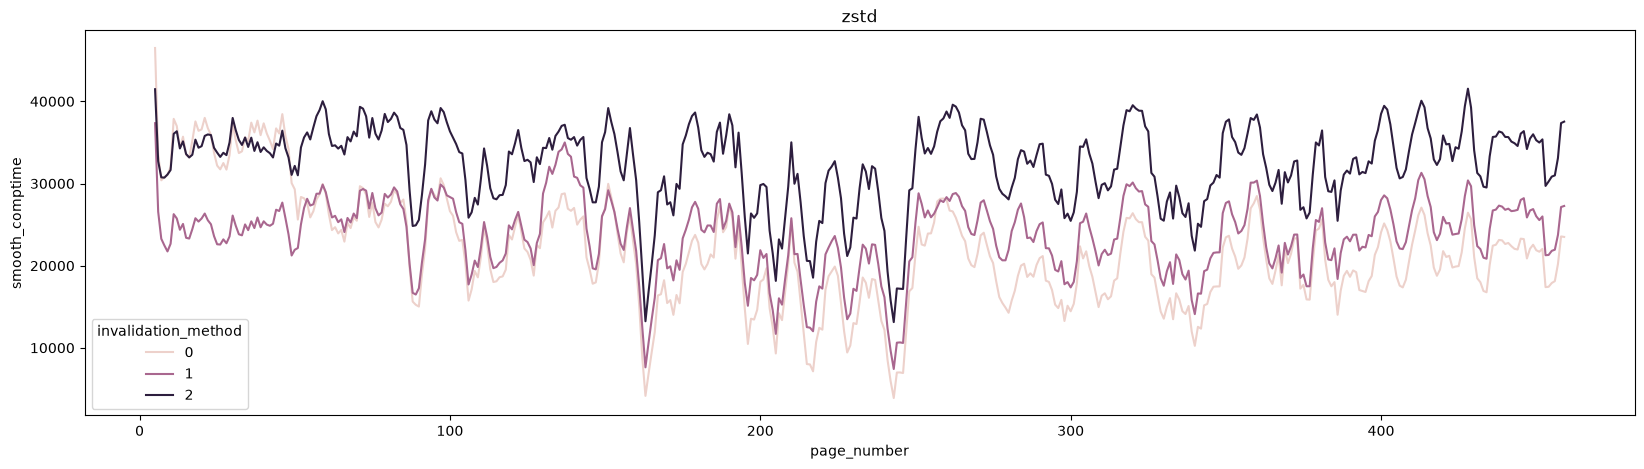

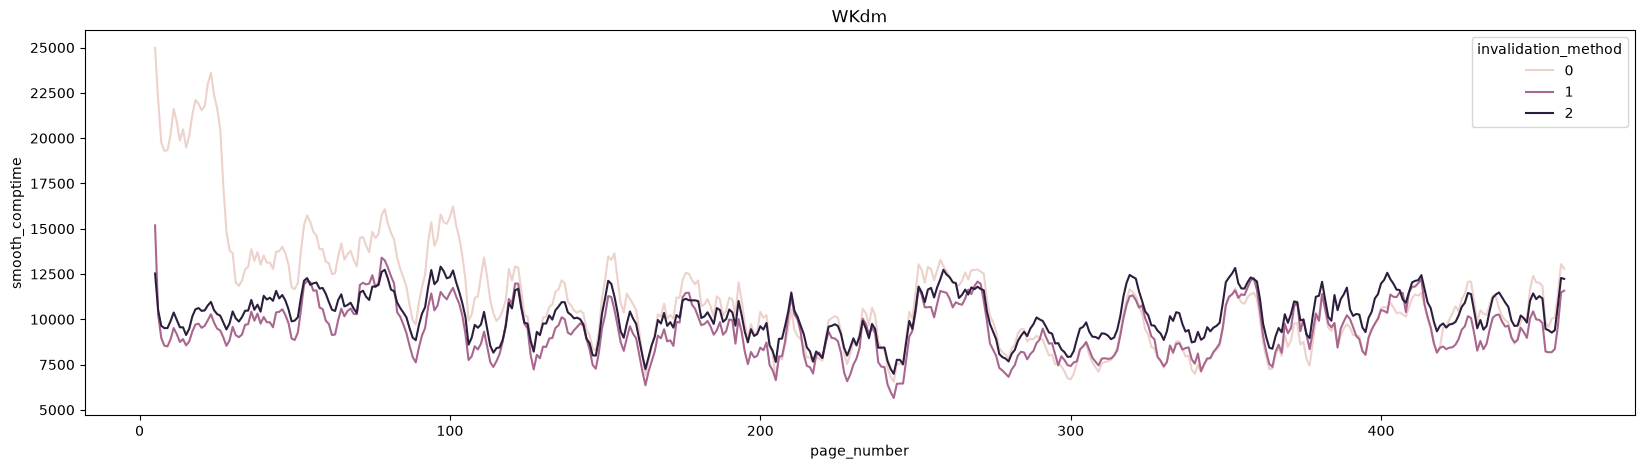

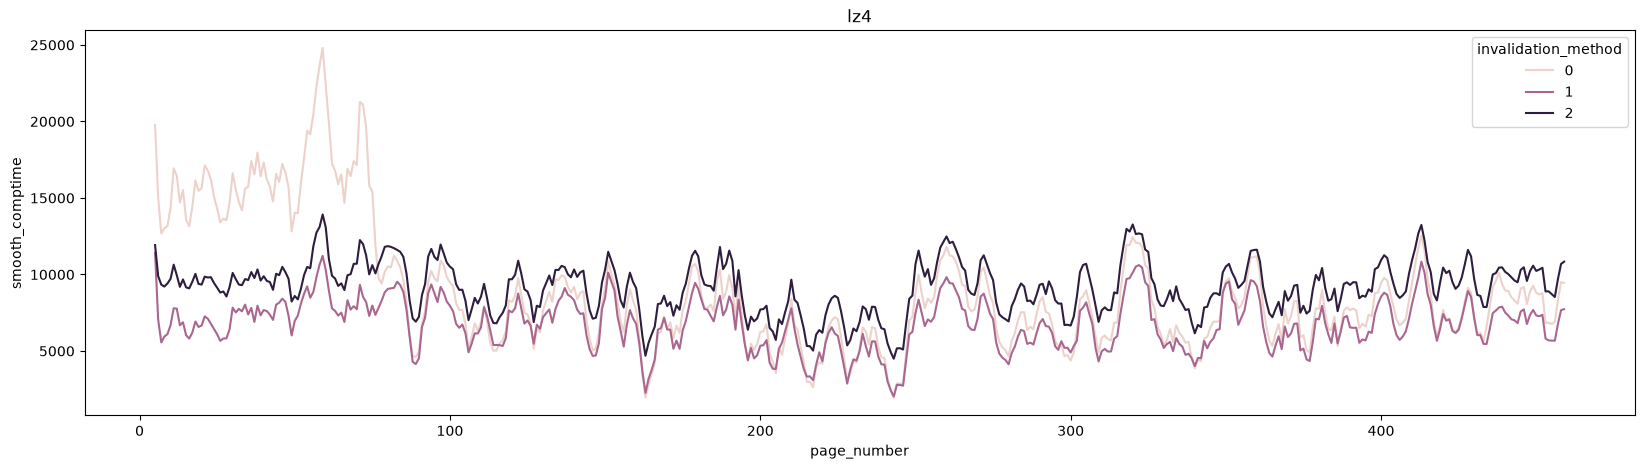

In [13]:
df1 = df.with_columns(
    pl.col("compression_time")
    .rolling_mean(window_size=5)
    .over(["alg", "invalidation_method"])
    .alias("smooth_comptime")
)

for alg in df["alg"].unique().to_list():
    plt.figure(figsize=(20,5))
    ax = sns.lineplot(
        df1.filter(pl.col("alg") == alg),
        x="page_number",
        y="smooth_comptime",
        hue="invalidation_method"
    )
    ax.set_title(alg)

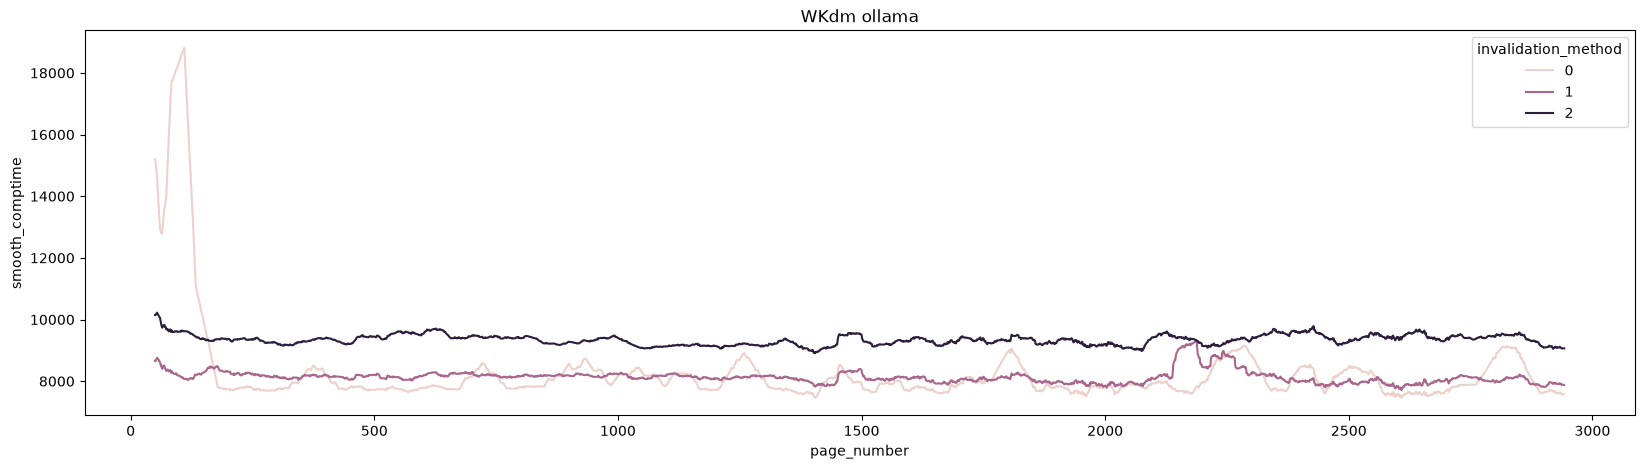

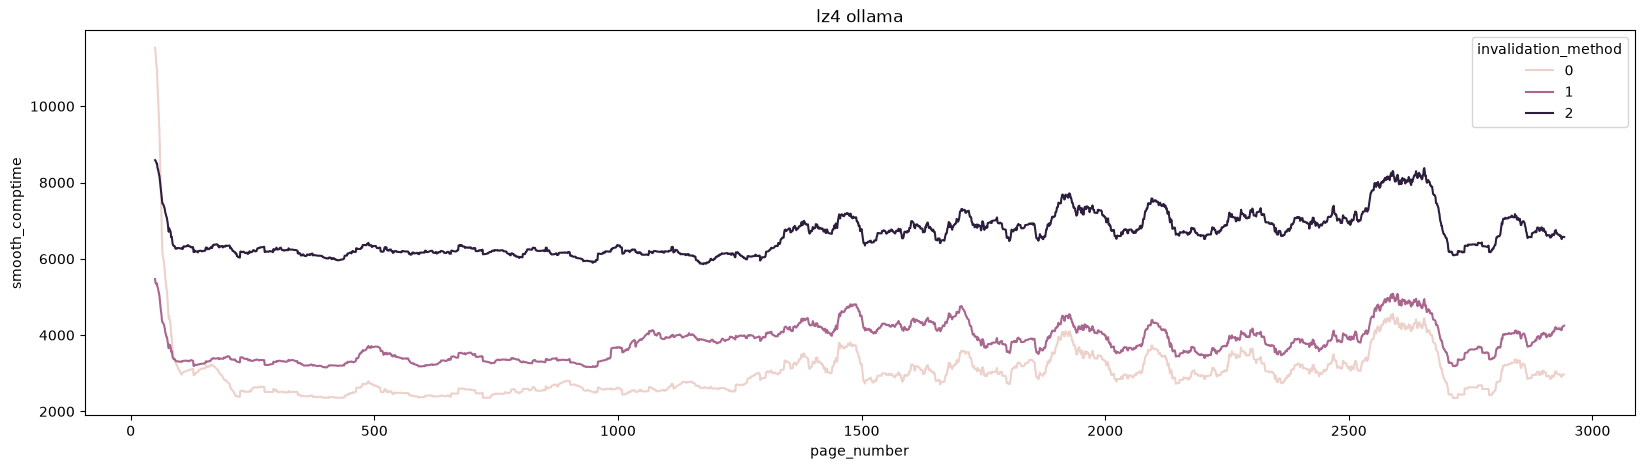

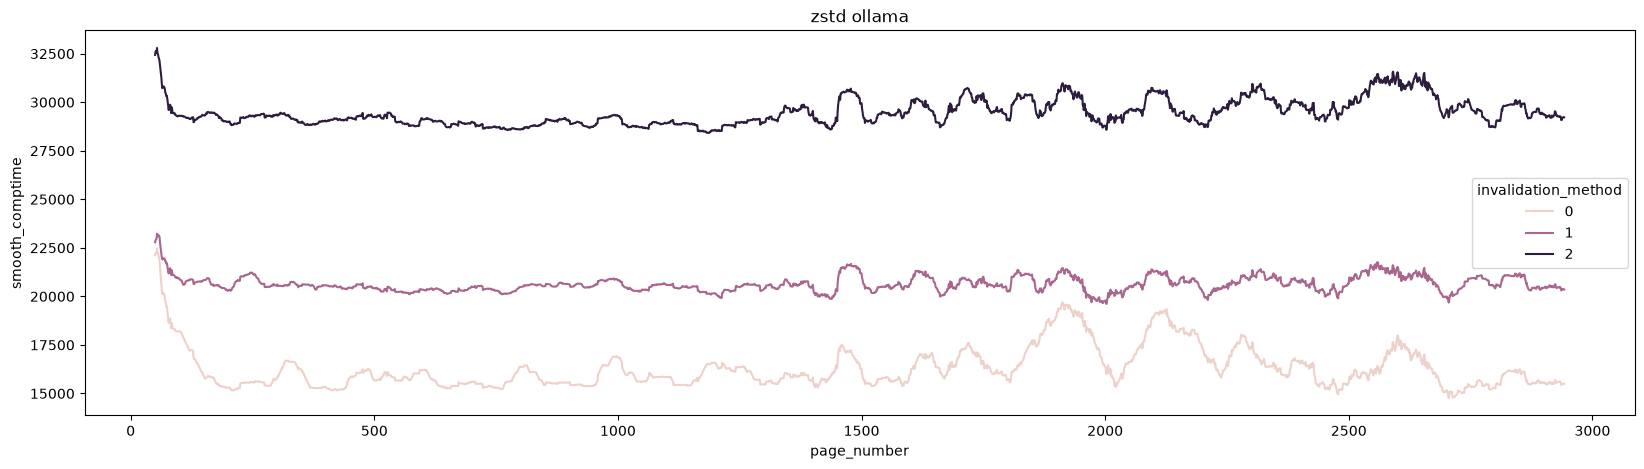

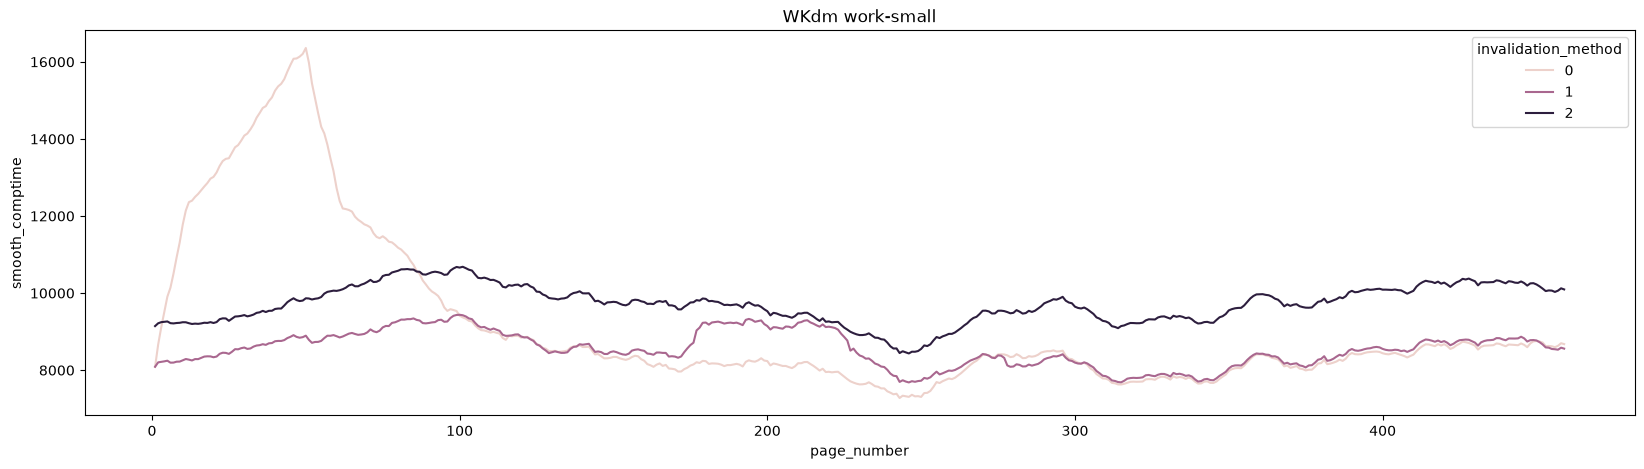

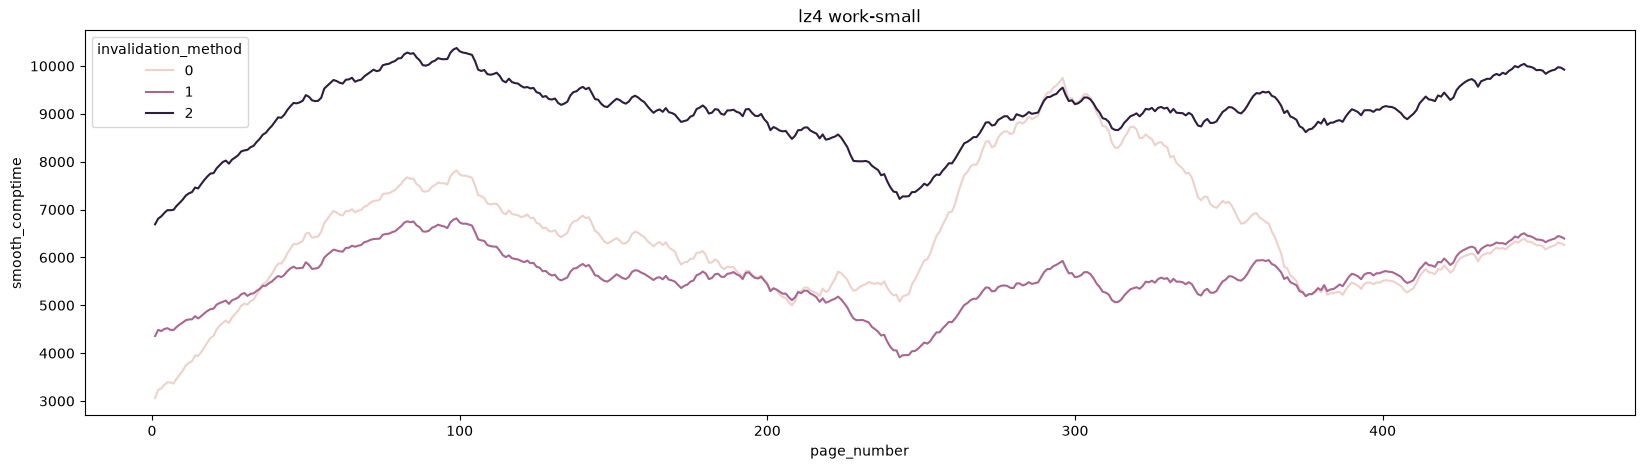

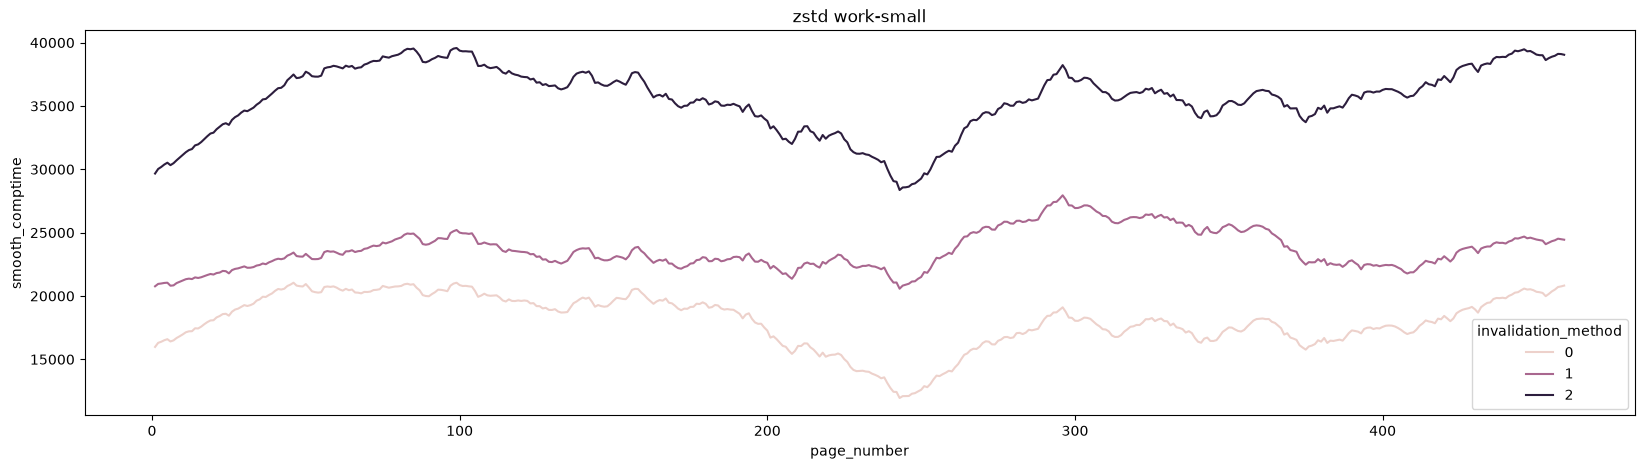

In [17]:

df1 = df.with_columns(
    pl.col("compression_time")
    .rolling_mean(window_size=50)
    .over(["alg", "invalidation_method"])
    .alias("smooth_comptime")
)

for trace in df["trace"].unique().to_list():
    for alg in df["alg"].unique().to_list():
        plt.figure(figsize=(20,5))
        ax = sns.lineplot(
            df1.filter(
                pl.col("trace") == trace,
                pl.col("alg") == alg
                ),
            x="page_number",
            y="smooth_comptime",
            hue="invalidation_method"
        )
        ax.set_title(f"{alg} {trace}")